1. Préparation des données
Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

In [2]:
# Chargement des données

pokemon = pd.read_csv("pokemon.csv")
combats = pd.read_csv("combats.csv")

print(pokemon.shape)
print(combats.shape)

pokemon.head()

(800, 12)
(50000, 3)


,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
0,1,Bulbasaur,Grass,Poison,45,49,49,65,65,45,1,False
1,2,Ivysaur,Grass,Poison,60,62,63,80,80,60,1,False
2,3,Venusaur,Grass,Poison,80,82,83,100,100,80,1,False
3,4,Mega Venusaur,Grass,Poison,80,100,123,122,120,80,1,False
4,5,Charmander,Fire,NaN,39,52,43,60,50,65,1,False


In [3]:
# Vérification des valeurs manquantes
pokemon.isnull().sum()

#               0
Name            1
Type 1          0
Type 2        386
HP              0
Attack          0
Defense         0
Sp. Atk         0
Sp. Def         0
Speed           0
Generation      0
Legendary       0
dtype: int64

In [4]:
# Correction du Pokémon n°62 (Primeape)
pokemon.loc[pokemon["Name"].isnull(), "Name"] = "Primeape"
pokemon[pokemon["Name"]=="Primeape"]

,#,Name,Type 1,Type 2,HP,Attack,Defense,Sp. Atk,Sp. Def,Speed,Generation,Legendary
62,63,Primeape,Fighting,NaN,65,105,60,60,70,95,1,False


In [5]:
# Gestion des valeurs manquantes de Type 2
pokemon["Type 2"] = pokemon["Type 2"].fillna("None")

In [6]:
# Calcul du pourcentage de victoire
# Nombre de victoires
wins = combats["Winner"].value_counts()


In [7]:
# Nombre de combats disputés
appearances = pd.concat([
    combats["First_pokemon"],
    combats["Second_pokemon"]
]).value_counts()

In [8]:
# Win Rate
win_rate = wins / appearances

pokemon["WinRate"] = pokemon["#"].map(win_rate)

pokemon["WinRate"] = pokemon["WinRate"].fillna(0)

2. Analyse exploratoire
Corrélation

In [9]:
corr_data = pokemon[
    [
        "HP",
        "Attack",
        "Defense",
        "Sp. Atk",
        "Sp. Def",
        "Speed",
        "WinRate"
    ]
]

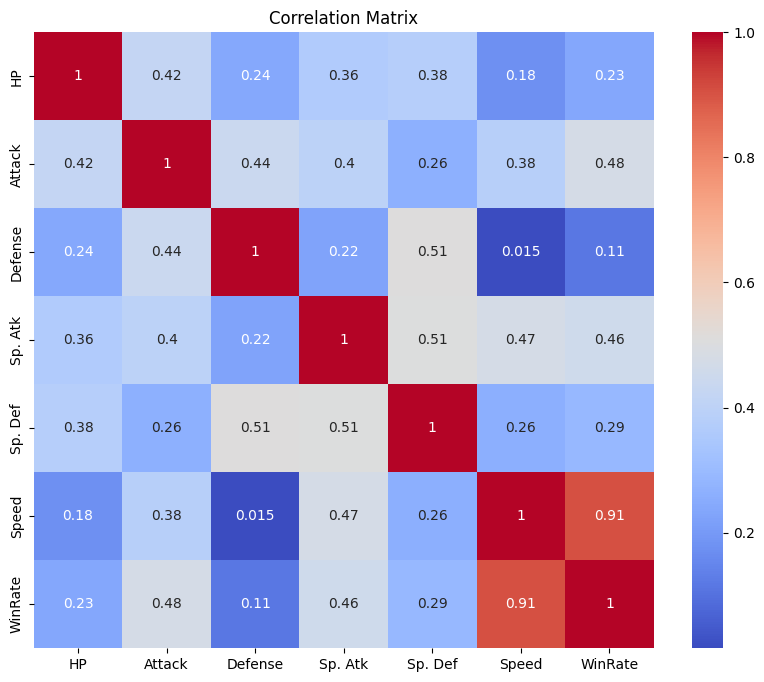

In [10]:
# Matrice de corrélation
plt.figure(figsize=(10,8))

sns.heatmap(
    corr_data.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.show()

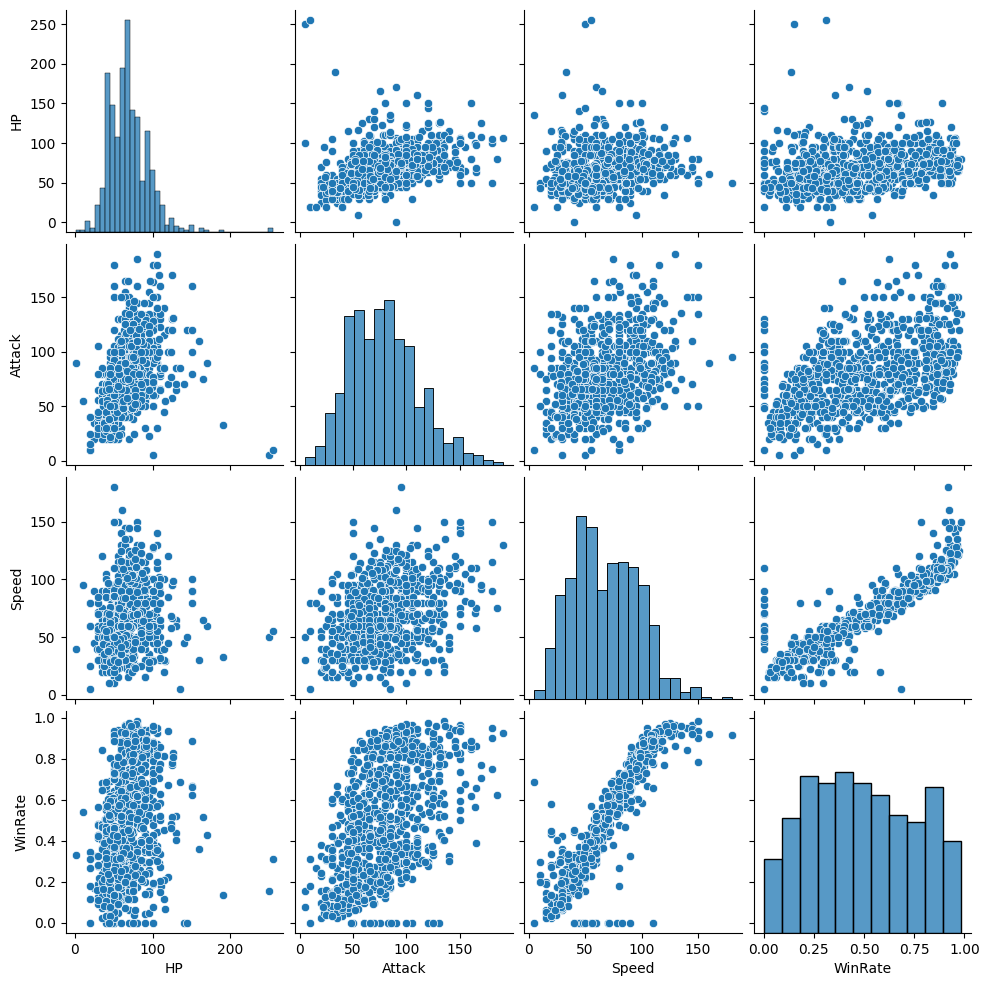

In [11]:
# Pairplot
sns.pairplot(
    pokemon[
        [
            "HP",
            "Attack",
            "Speed",
            "WinRate"
        ]
    ]
)

plt.show()

In [12]:
# Top 10 Pokémon

top10 = pokemon.sort_values(
    "WinRate",
    ascending=False
).head(10)

top10[
    [
        "Name",
        "HP",
        "Attack",
        "Defense",
        "Speed",
        "WinRate"
    ]
]

,Name,HP,Attack,Defense,Speed,WinRate
154,Mega Aerodactyl,80,135,85,150,0.984496
512,Weavile,70,120,65,125,0.974790
703,Tornadus Therian Forme,79,100,80,121,0.968000
19,Mega Beedrill,65,150,40,145,0.966387
153,Aerodactyl,80,105,65,130,0.964539
476,Mega Lopunny,65,136,94,135,0.961240
726,Greninja,72,95,67,122,0.960630
716,Meloetta Pirouette Forme,100,128,90,128,0.959350
164,Mega Mewtwo Y,106,150,70,140,0.952000
349,Mega Sharpedo,70,140,70,105,0.950000


3. Machine Learning
Variables explicatives

In [13]:
features = [
    "HP",
    "Attack",
    "Defense",
    "Sp. Atk",
    "Sp. Def",
    "Speed"
]

X = pokemon[features]
y = pokemon["WinRate"]

In [14]:
# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [15]:
# Modèle 1 : Régression Linéaire

lr = LinearRegression()

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(
    y_test,
    pred_lr
)

print("MAE Linear Regression :", mae_lr)

MAE Linear Regression : 0.06491538345586538


In [16]:
# Modèle 2 : Random Forest
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(
    y_test,
    pred_rf
)

print("MAE Random Forest :", mae_rf)

MAE Random Forest : 0.05732858147676236


In [17]:
# Modèle 3 : XGBoost

xgb = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(
    y_test,
    pred_xgb
)

print("MAE XGBoost :", mae_xgb)

MAE XGBoost : 0.0563818658680606


In [18]:
# Comparaison des modèles
results = pd.DataFrame({
    "Model":[
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],
    "MAE":[
        mae_lr,
        mae_rf,
        mae_xgb
    ]
})

results.sort_values("MAE")

,Model,MAE
2,XGBoost,0.056382
1,Random Forest,0.057329
0,Linear Regression,0.064915


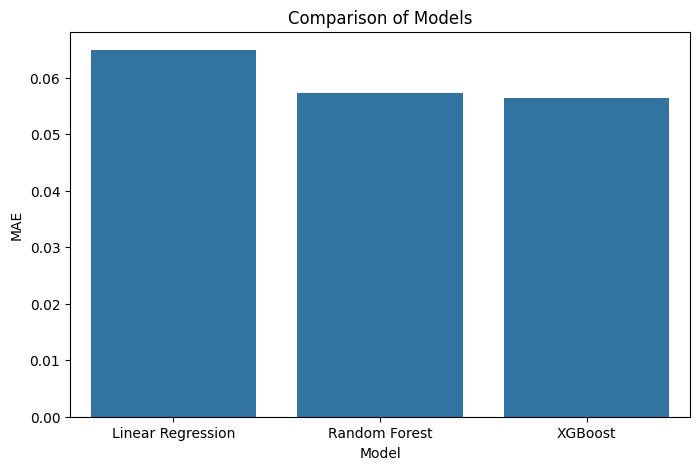

In [19]:
# Visualisation
plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="MAE"
)

plt.title("Comparison of Models")
plt.show()